# 🧑‍🏫 Aula 6 — NLP: Análise de Sentimento com Redes Neurais

**UC:** Machine Learning | **Data:** 20/05/2026 | **Duração:** 3 horas

---

## 🎯 Objetivos desta Aula

Na **Aula 5** construímos redes neurais (MLP e CNN) para **dados tabulares e imagens**. Agora vamos aplicá-las a um terceiro tipo de dado fundamental: **texto**.

O problema: uma grande varejista de moda recebe **milhares de reviews** diárias de clientes. Precisamos **classificar automaticamente** se uma review indica que o cliente **recomenda** ou **não recomenda** o produto — isso é **análise de sentimento binária**.

Vamos construir **duas abordagens** e compará-las:

1. 📊 **Baseline com ML clássico:** TF-IDF + Logistic Regression / Naive Bayes
2. 🧠 **Rede Neural para NLP:** Embedding → LSTM/GRU → Dense

### O que você vai aprender nesta aula:

1. 📝 **Pré-processamento de texto:** tokenização, remoção de stopwords, lemmatização
2. 📊 **TF-IDF** — como transformar texto em vetores numéricos para ML clássico
3. 🧠 **Embedding Layer** — como a rede neural aprende representações densas de palavras
4. 🔄 **LSTM e GRU** — redes recorrentes que capturam contexto sequencial
5. ⚖️ **Comparação ML clássico vs Rede Neural** via MLflow
6. 📊 **Avaliação detalhada:** confusion matrix, análise de erros por categoria de produto
7. 🦾 **Discussão ética:** viés em reviews, representatividade, impacto de decisões automatizadas

### Recapitulando a trilha:

| Aula | Paradigma | Algoritmos | Tipo de dado |
|---|---|---|---|
| 1 | Supervisionado (classif.) | RandomForest | Tabular |
| 2 | Supervisionado (classif.) | SVM, KNN, XGBoost, LightGBM | Tabular |
| 3 | Supervisionado (regressão) | Ridge, Lasso, SVR, XGBRegressor | Tabular |
| 4 | Não supervisionado | Isolation Forest, LOF, OCSVM, DBSCAN | Tabular |
| 5 | Supervisionado (redes neurais) | MLP (tabular) + CNN (imagem) | Tabular + Imagem |
| **6** | **Supervisionado (NLP)** | **TF-IDF + LR/NB, Embedding + LSTM/GRU** | **Texto** |

---

📦 **Dataset:** [Women's E-Commerce Clothing Reviews](https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews) — 23K reviews com texto, rating e flag de recomendação

> 💡 **Contexto industrial:** Na indústria têxtil, entender o sentimento de clientes sobre tecidos, acabamento e caimento é crítico para ajustar produção, priorizar fornecedores e evitar devoluções.

## 1️⃣ Configuração do Ambiente e Importação de Bibliotecas

Nesta aula usamos bibliotecas já conhecidas + algumas novas para **processamento de texto**:

| Biblioteca | Para que serve | Novidade? |
|---|---|---|
| `pandas` / `numpy` | Manipulação de dados | — |
| `matplotlib` / `seaborn` | Visualizações | — |
| `scikit-learn` | TF-IDF, Logistic Regression, Naive Bayes, métricas | — |
| `nltk` | **Tokenização, stopwords, lemmatização** | ✅ **Novo** |
| `tensorflow` / `keras` | Embedding + LSTM/GRU para NLP | — (usado na Aula 5) |
| `mlflow` | Tracking de experimentos | — |
| `joblib` | Salvar vetorizadores e modelos | — |

In [1]:
# ============================================================
# INSTALAÇÃO DAS DEPENDÊNCIAS
# ============================================================
# NLTK é a grande novidade para processamento de texto.
# As demais já foram instaladas nas aulas anteriores.

!pip install -q pandas numpy matplotlib seaborn scikit-learn mlflow joblib tensorflow nltk kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 88.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 88.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

# --- Reduz verbosidade do TensorFlow ---
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# --- Manipulação de Dados ---
import pandas as pd
import numpy as np

# --- Visualização ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Processamento de Texto (NLP) ---
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# --- Scikit-learn (TF-IDF, modelos clássicos, métricas) ---
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

# --- TensorFlow / Keras para redes neurais de NLP ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# --- Tracking de experimentos ---
import mlflow

# --- Utilitários ---
import joblib
import warnings
warnings.filterwarnings("ignore")

# --- Download de recursos do NLTK ---
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

# --- Configuração visual ---
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# --- Reprodutibilidade ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

print("✅ Todas as bibliotecas foram importadas com sucesso!")
print(f"   🧠 TensorFlow: {tf.__version__}")
print(f"   📝 NLTK:       {nltk.__version__}")
print(f"   💻 GPU disponível? {'Sim' if tf.config.list_physical_devices('GPU') else 'Não (usando CPU)'}")

✅ Todas as bibliotecas foram importadas com sucesso!
   🧠 TensorFlow: 2.20.0
   📝 NLTK:       3.9.1
   💻 GPU disponível? Não (usando CPU)


## 2️⃣ Carregamento e Exploração do Dataset

O dataset **Women's E-Commerce Clothing Reviews** contém reviews reais de uma loja online de roupas femininas. Cada review inclui:

| Coluna | Descrição |
|---|---|
| `Review Text` | Texto da avaliação escrita pelo cliente |
| `Rating` | Nota de 1 a 5 estrelas |
| `Recommended IND` | **1** = recomenda, **0** = não recomenda (nosso **target**) |
| `Division Name` | Divisão do produto (General, Petite, Intimates) |
| `Department Name` | Departamento (Tops, Dresses, Bottoms, Intimate, Jackets, Trend) |
| `Class Name` | Classe específica (Knits, Dresses, Blouses, Pants, etc.) |
| `Age` | Idade do cliente |

Nosso alvo é a coluna `Recommended IND` — vamos prever se o cliente recomenda ou não o produto **apenas com base no texto da review**.

In [3]:
# ============================================================
# 2.1 — DOWNLOAD E CARREGAMENTO DO DATASET
# ============================================================
# Usamos kagglehub para baixar o dataset diretamente.

import kagglehub

# Download do dataset
path = kagglehub.dataset_download("nicapotato/womens-ecommerce-clothing-reviews")
print(f"📥 Dataset baixado em: {path}")

# Listar arquivos disponíveis
for f in os.listdir(path):
    print(f"   📄 {f}")

100%|██████████| 2.79M/2.79M [00:00<00:00, 132MB/s]

Extracting files...
📥 Dataset baixado em: /root/.cache/kagglehub/datasets/nicapotato/womens-ecommerce-clothing-reviews/versions/1
   📄 Womens Clothing E-Commerce Reviews.csv


In [4]:
# ============================================================
# 2.2 — LEITURA DO CSV E PRIMEIRAS OBSERVAÇÕES
# ============================================================

# O dataset tem um arquivo CSV principal
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"📊 Shape do dataset: {df.shape[0]:,} reviews x {df.shape[1]} colunas")
print(f"\n📋 Colunas disponíveis:")
for col in df.columns:
    nulos = df[col].isna().sum()
    print(f"   • {col:<25} | tipo: {str(df[col].dtype):<10} | nulos: {nulos:,}")

print(f"\n👀 Primeiras 3 reviews:")
df[["Review Text", "Rating", "Recommended IND", "Department Name"]].head(3)

📊 Shape do dataset: 23,486 reviews x 11 colunas

📋 Colunas disponíveis:
   • Unnamed: 0                | tipo: int64      | nulos: 0
   • Clothing ID               | tipo: int64      | nulos: 0
   • Age                       | tipo: int64      | nulos: 0
   • Title                     | tipo: object     | nulos: 3,810
   • Review Text               | tipo: object     | nulos: 845
   • Rating                    | tipo: int64      | nulos: 0
   • Recommended IND           | tipo: int64      | nulos: 0
   • Positive Feedback Count   | tipo: int64      | nulos: 0
   • Division Name             | tipo: object     | nulos: 14
   • Department Name           | tipo: object     | nulos: 14
   • Class Name                | tipo: object     | nulos: 14

👀 Primeiras 3 reviews:


,Review Text,Rating,Recommended IND,Department Name
0,Absolutely wonderful - silky and sexy and comf...,4,1,Intimate
1,Love this dress! it's sooo pretty. i happene...,5,1,Dresses
2,I had such high hopes for this dress and reall...,3,0,Dresses


In [5]:
# ============================================================
# 2.3 — LIMPEZA INICIAL: REMOVER REVIEWS VAZIAS
# ============================================================
# Precisamos de texto para fazer NLP! Reviews sem texto são inúteis.

print(f"Reviews com texto vazio/nulo: {df['Review Text'].isna().sum():,}")

# Remover linhas onde 'Review Text' é nulo
df = df.dropna(subset=["Review Text"]).reset_index(drop=True)
print(f"✅ Após remover nulos: {df.shape[0]:,} reviews")

# Definir target e texto
TARGET = "Recommended IND"
TEXT_COL = "Review Text"

print(f"\n🎯 Distribuição do target ({TARGET}):")
dist = df[TARGET].value_counts()
for val, count in dist.items():
    label = "Recomenda" if val == 1 else "Não recomenda"
    print(f"   {val} ({label}): {count:,} ({count/len(df)*100:.1f}%)")

Reviews com texto vazio/nulo: 845
✅ Após remover nulos: 22,641 reviews

🎯 Distribuição do target (Recommended IND):
   1 (Recomenda): 18,540 (81.9%)
   0 (Não recomenda): 4,101 (18.1%)


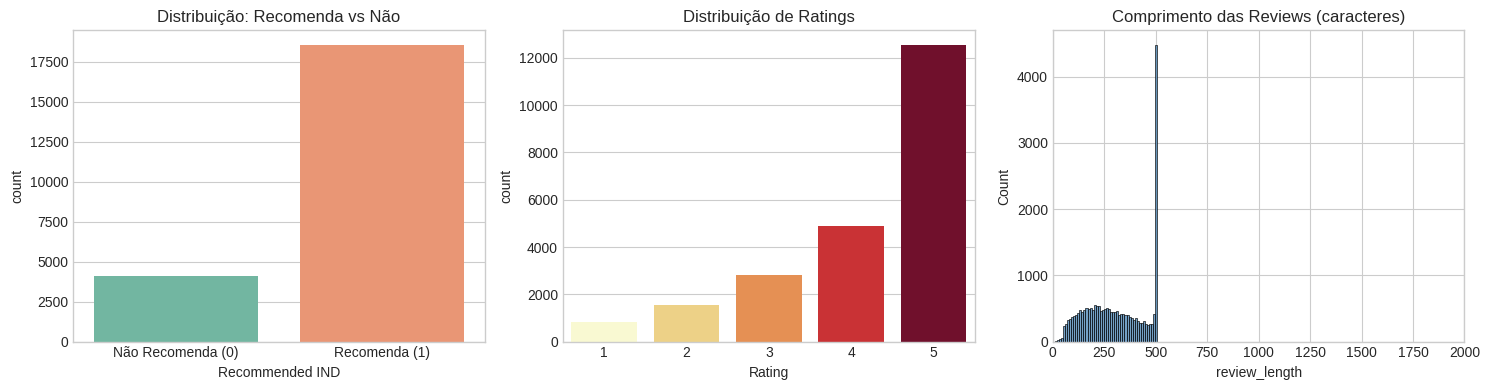


📏 Comprimento das reviews (caracteres):
   Média:   309
   Mediana:  301
   Máximo:  508

⭐ Rating médio por recomendação:
   Não recomenda: 2.30
   Recomenda:     4.60


In [6]:
# ============================================================
# 2.4 — ANÁLISE EXPLORATÓRIA (EDA)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Distribuição do target ---
sns.countplot(data=df, x=TARGET, ax=axes[0], hue=TARGET, palette="Set2", legend=False)
axes[0].set_title("Distribuição: Recomenda vs Não")
axes[0].set_xticklabels(["Não Recomenda (0)", "Recomenda (1)"])

# --- Distribuição de ratings ---
sns.countplot(data=df, x="Rating", ax=axes[1], hue="Rating", palette="YlOrRd", legend=False)
axes[1].set_title("Distribuição de Ratings")

# --- Comprimento das reviews ---
df["review_length"] = df[TEXT_COL].str.len()
sns.histplot(data=df, x="review_length", bins=50, ax=axes[2], color="steelblue")
axes[2].set_title("Comprimento das Reviews (caracteres)")
axes[2].set_xlim(0, 2000)

plt.tight_layout()
plt.show()

# Estatísticas do comprimento
print(f"\n📏 Comprimento das reviews (caracteres):")
print(f"   Média:   {df['review_length'].mean():.0f}")
print(f"   Mediana:  {df['review_length'].median():.0f}")
print(f"   Máximo:  {df['review_length'].max():,}")

# Rating médio por recomendação
print(f"\n⭐ Rating médio por recomendação:")
print(f"   Não recomenda: {df[df[TARGET]==0]['Rating'].mean():.2f}")
print(f"   Recomenda:     {df[df[TARGET]==1]['Rating'].mean():.2f}")

## 3️⃣ Pré-processamento de Texto

Texto "cru" não pode ser usado diretamente por modelos de ML. Precisamos **transformar** o texto em algo que o computador entenda. O pipeline clássico de NLP é:

```
Texto bruto → lowercase → remover pontuação/números → tokenizar → remover stopwords → lemmatizar → texto limpo
```

### Glossário:

| Termo | O que faz | Exemplo |
|---|---|---|
| **Tokenização** | Quebra o texto em palavras individuais | `"I love this dress"` → `["I", "love", "this", "dress"]` |
| **Stopwords** | Palavras muito frequentes sem significado semântico | `"the"`, `"is"`, `"a"`, `"in"` |
| **Lemmatização** | Reduz palavras à forma base (lema) | `"running"` → `"run"`, `"dresses"` → `"dress"` |
| **TF-IDF** | Peso que valoriza palavras raras e penaliza comuns | Palavra rara num doc = peso alto |
| **Padding** | Igualar o tamanho das sequências (redes neurais exigem) | Sequências menores recebem zeros à esquerda |

In [7]:
# ============================================================
# 3.1 — FUNÇÃO DE PRÉ-PROCESSAMENTO DE TEXTO
# ============================================================
# Esta função aplica todo o pipeline de limpeza num texto.

# Carregar stopwords em inglês e o lemmatizador
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocessar_texto(texto: str) -> str:
    """
    Pipeline completo de pré-processamento de texto:
    1. Converte para minúsculo
    2. Remove números e caracteres especiais
    3. Tokeniza (quebra em palavras)
    4. Remove stopwords
    5. Lemmatiza (reduz à forma base)
    6. Junta de volta em string
    """
    # 1. Lowercase
    texto = texto.lower()

    # 2. Remover números e caracteres especiais (manter só letras e espaços)
    texto = re.sub(r"[^a-z\s]", "", texto)

    # 3. Tokenizar
    tokens = word_tokenize(texto)

    # 4. Remover stopwords e palavras muito curtas
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # 5. Lemmatizar
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # 6. Juntar de volta
    return " ".join(tokens)


# Demonstração com uma review real
exemplo = df[TEXT_COL].iloc[0]
print("📝 Texto ORIGINAL:")
print(f"   '{exemplo[:200]}...'")
print(f"\n✅ Texto PRÉ-PROCESSADO:")
print(f"   '{preprocessar_texto(exemplo)[:200]}...'")

📝 Texto ORIGINAL:
   'Absolutely wonderful - silky and sexy and comfortable...'

✅ Texto PRÉ-PROCESSADO:
   'absolutely wonderful silky sexy comfortable...'


In [8]:
# ============================================================
# 3.2 — APLICAR PRÉ-PROCESSAMENTO A TODAS AS REVIEWS
# ============================================================
# Isso pode demorar ~1-2 minutos para 22K reviews.

print("⏳ Pré-processando todas as reviews... (pode levar 1-2 min)")
df["texto_limpo"] = df[TEXT_COL].apply(preprocessar_texto)

# Remover reviews que ficaram vazias após limpeza
vazias = (df["texto_limpo"].str.strip() == "").sum()
print(f"   Reviews que ficaram vazias após limpeza: {vazias}")
df = df[df["texto_limpo"].str.strip() != ""].reset_index(drop=True)

print(f"✅ Pré-processamento concluído! {len(df):,} reviews prontas.")
print(f"\n📊 Exemplo de reviews limpas:")
for i in range(3):
    print(f"   [{df[TARGET].iloc[i]}] {df['texto_limpo'].iloc[i][:80]}...")

⏳ Pré-processando todas as reviews... (pode levar 1-2 min)
   Reviews que ficaram vazias após limpeza: 0
✅ Pré-processamento concluído! 22,641 reviews prontas.

📊 Exemplo de reviews limpas:
   [1] absolutely wonderful silky sexy comfortable...
   [1] love dress sooo pretty happened find store glad never would ordered online petit...
   [0] high hope dress really wanted work initially ordered petite small usual size fou...


## 4️⃣ Divisão Treino / Validação / Teste

Dividimos em **3 partições** (assim como fizemos nas aulas anteriores):
- **Treino (70%)** — para ajustar os pesos dos modelos
- **Validação (15%)** — para monitorar overfitting durante o treino
- **Teste (15%)** — para avaliação final imparcial

Usamos `stratify` para manter a mesma proporção de classes em cada partição.

In [9]:
# ============================================================
# 4.1 — SPLIT TREINO / VALIDAÇÃO / TESTE (70/15/15)
# ============================================================

X = df["texto_limpo"].values   # Textos pré-processados
y = df[TARGET].values           # 0 ou 1

# Primeiro split: 70% treino, 30% restante
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Segundo split: 50% do restante para val, 50% para teste (= 15% + 15% do total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"✅ Divisão dos dados:")
print(f"   Treino:     {len(X_train):,} reviews ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Validação:  {len(X_val):,} reviews ({len(X_val)/len(X)*100:.0f}%)")
print(f"   Teste:      {len(X_test):,} reviews ({len(X_test)/len(X)*100:.0f}%)")

# Verifica distribuição do target em cada partição
print(f"\n🎯 Proporção de 'Recomenda' (classe 1):")
print(f"   Treino:     {y_train.mean():.3f}")
print(f"   Validação:  {y_val.mean():.3f}")
print(f"   Teste:      {y_test.mean():.3f}")

✅ Divisão dos dados:
   Treino:     15,848 reviews (70%)
   Validação:  3,396 reviews (15%)
   Teste:      3,397 reviews (15%)

🎯 Proporção de 'Recomenda' (classe 1):
   Treino:     0.819
   Validação:  0.819
   Teste:      0.819


## 5️⃣ Abordagem 1: Baseline com ML Clássico (TF-IDF + Logistic Regression / Naive Bayes)

### O que é TF-IDF?

**TF-IDF (Term Frequency – Inverse Document Frequency)** transforma texto em vetores numéricos:

- **TF (Term Frequency):** quantas vezes a palavra aparece no documento
- **IDF (Inverse Document Frequency):** penaliza palavras que aparecem em MUITOS documentos (ex: `"dress"` em reviews de roupa)
- **TF-IDF = TF × IDF** — palavras **raras num contexto** ganham peso alto

### Por que usar como baseline?

TF-IDF + modelos lineares é **rápido, interpretável e surpreendentemente eficaz** para muitos problemas de NLP. É o ponto de partida ideal antes de usar redes neurais.

Vamos testar dois classificadores:
1. **Logistic Regression** — robusto, rápido, bom com features esparsas
2. **Multinomial Naive Bayes** — clássico de NLP, muito rápido

In [10]:
# ============================================================
# 5.1 — VETORIZAÇÃO COM TF-IDF
# ============================================================
# Transformamos os textos em vetores numéricos (matrizes esparsas).
# max_features=10000 limita o vocabulário às 10K palavras mais relevantes.
# ngram_range=(1,2) captura unigramas E bigramas (ex: "not good").

tfidf = TfidfVectorizer(
    max_features=10000,       # Vocabulário máximo de 10K palavras
    ngram_range=(1, 2),       # Unigramas e bigramas
    min_df=3,                 # Ignorar palavras que aparecem em < 3 docs
    max_df=0.95,              # Ignorar palavras em > 95% dos docs
)

# Fit no treino, transform em val e teste
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f"✅ TF-IDF vetorizado:")
print(f"   Shape treino:  {X_train_tfidf.shape} (docs × features)")
print(f"   Vocabulário:   {len(tfidf.vocabulary_):,} termos")
print(f"   Exemplo de termos: {list(tfidf.vocabulary_.keys())[:10]}")

✅ TF-IDF vetorizado:
   Shape treino:  (15848, 10000) (docs × features)
   Vocabulário:   10,000 termos
   Exemplo de termos: ['love', 'dress', 'splurged', 'christmas', 'shopping', 'get', 'glad', 'comfortable', 'stretchy', 'thin']


In [11]:
# ============================================================
# 5.2 — CONFIGURAÇÃO DO MLFLOW
# ============================================================

# Diretório para artefatos do MLflow
MLFLOW_DIR = "mlruns"
mlflow.set_tracking_uri(f"file:./{MLFLOW_DIR}")

# Criar experimento para esta aula
EXPERIMENT_NAME = "aula06_nlp_sentimento"
mlflow.set_experiment(EXPERIMENT_NAME)

# Diretório para salvar modelos finais
MODELOS_DIR = "../modelos/aula06"
os.makedirs(MODELOS_DIR, exist_ok=True)

print(f"✅ MLflow configurado:")
print(f"   Experimento: {EXPERIMENT_NAME}")
print(f"   Tracking:    ./{MLFLOW_DIR}")
print(f"   Modelos:     {MODELOS_DIR}")

2026/05/21 00:24:12 INFO mlflow.tracking.fluent: Experiment with name 'aula06_nlp_sentimento' does not exist. Creating a new experiment.


✅ MLflow configurado:
   Experimento: aula06_nlp_sentimento
   Tracking:    ./mlruns
   Modelos:     ../modelos/aula06


In [12]:
# ============================================================
# 5.3 — LOGISTIC REGRESSION + TF-IDF
# ============================================================
# Logistic Regression é um dos melhores modelos para TF-IDF:
# - Rápido de treinar
# - Funciona bem com features esparsas (alta dimensionalidade)
# - Coeficientes são interpretáveis

with mlflow.start_run(run_name="baseline_logistic_regression"):
    # Treinar
    lr = LogisticRegression(
        max_iter=1000,
        C=1.0,                # Regularização (menor = mais regularizado)
        random_state=RANDOM_STATE,
    )
    lr.fit(X_train_tfidf, y_train)

    # Predizer no teste
    y_pred_lr = lr.predict(X_test_tfidf)
    y_proba_lr = lr.predict_proba(X_test_tfidf)[:, 1]

    # Métricas
    acc_lr  = accuracy_score(y_test, y_pred_lr)
    f1_lr   = f1_score(y_test, y_pred_lr)
    prec_lr = precision_score(y_test, y_pred_lr)
    rec_lr  = recall_score(y_test, y_pred_lr)
    auc_lr  = roc_auc_score(y_test, y_proba_lr)

    # Logging no MLflow
    mlflow.log_params({"modelo": "LogisticRegression", "vetorizador": "TF-IDF",
                       "max_features": 10000, "ngram_range": "(1,2)", "C": 1.0})
    mlflow.log_metrics({"accuracy": acc_lr, "f1": f1_lr, "precision": prec_lr,
                        "recall": rec_lr, "roc_auc": auc_lr})

print(f"\n📊 Logistic Regression + TF-IDF:")
print(f"   Accuracy:  {acc_lr:.4f}")
print(f"   F1-Score:  {f1_lr:.4f}")
print(f"   Precision: {prec_lr:.4f}")
print(f"   Recall:    {rec_lr:.4f}")
print(f"   ROC-AUC:   {auc_lr:.4f}")


📊 Logistic Regression + TF-IDF:
   Accuracy:  0.8808
   F1-Score:  0.9303
   Precision: 0.8921
   Recall:    0.9720
   ROC-AUC:   0.9255


In [13]:
# ============================================================
# 5.4 — NAIVE BAYES + TF-IDF
# ============================================================
# MultinomialNB é o classificador clássico para NLP:
# - MUITO rápido (treino quase instantâneo)
# - Assume independência entre features (simplificação forte mas funcional)
# - Bom baseline para comparação

with mlflow.start_run(run_name="baseline_naive_bayes"):
    # Treinar
    nb = MultinomialNB(alpha=1.0)  # alpha = suavização de Laplace
    nb.fit(X_train_tfidf, y_train)

    # Predizer no teste
    y_pred_nb = nb.predict(X_test_tfidf)
    y_proba_nb = nb.predict_proba(X_test_tfidf)[:, 1]

    # Métricas
    acc_nb  = accuracy_score(y_test, y_pred_nb)
    f1_nb   = f1_score(y_test, y_pred_nb)
    prec_nb = precision_score(y_test, y_pred_nb)
    rec_nb  = recall_score(y_test, y_pred_nb)
    auc_nb  = roc_auc_score(y_test, y_proba_nb)

    # Logging no MLflow
    mlflow.log_params({"modelo": "MultinomialNB", "vetorizador": "TF-IDF",
                       "max_features": 10000, "ngram_range": "(1,2)", "alpha": 1.0})
    mlflow.log_metrics({"accuracy": acc_nb, "f1": f1_nb, "precision": prec_nb,
                        "recall": rec_nb, "roc_auc": auc_nb})

print(f"\n📊 Naive Bayes + TF-IDF:")
print(f"   Accuracy:  {acc_nb:.4f}")
print(f"   F1-Score:  {f1_nb:.4f}")
print(f"   Precision: {prec_nb:.4f}")
print(f"   Recall:    {rec_nb:.4f}")
print(f"   ROC-AUC:   {auc_nb:.4f}")


📊 Naive Bayes + TF-IDF:
   Accuracy:  0.8552
   F1-Score:  0.9181
   Precision: 0.8549
   Recall:    0.9914
   ROC-AUC:   0.9206


## 6️⃣ Abordagem 2: Redes Neurais para NLP (Embedding + LSTM/GRU)

### Por que redes neurais para texto?

O TF-IDF trata cada documento como um **saco de palavras** (bag-of-words) — ele não entende **ordem** nem **contexto**. Por exemplo:
- `"this dress is not beautiful"` e `"this beautiful dress is not"` teriam o **mesmo** vetor TF-IDF!

Redes neurais recorrentes (LSTM/GRU) processam o texto **sequencialmente**, captando:
- **Ordem das palavras:** `"not good"` ≠ `"good, not"`
- **Contexto de longo prazo:** a rede "lembra" o que veio antes

### Arquitetura que vamos construir:

```
Texto → [Tokenizer + Padding] → [Embedding] → [LSTM/GRU] → [Dense + Sigmoid]
```

| Camada | Função | Analogia |
|---|---|---|
| **Embedding** | Transforma cada palavra em um vetor denso (ex: 64 dimensões) | Cada palavra vira um "ponto" no espaço |
| **LSTM/GRU** | Processa a sequência palavra por palavra, mantendo memória | Lê o texto da esquerda para direita, lembrando o contexto |
| **Dense** | Camada densa final para classificação | Decide: recomenda ou não? |
| **Sigmoid** | Função de ativação para saída binária (0 a 1) | Probabilidade de "recomenda" |

In [14]:
# ============================================================
# 6.1 — TOKENIZAÇÃO E PADDING PARA REDES NEURAIS
# ============================================================
# Para redes neurais, precisamos transformar texto em sequências de inteiros.
# Cada palavra recebe um índice numérico (ex: "love" = 42, "dress" = 15).
# Depois igualamos o tamanho com padding (zeros à esquerda).

# Hiperparâmetros
VOCAB_SIZE = 15000     # Tamanho máximo do vocabulário
MAX_LENGTH = 150       # Comprimento máximo da sequência (em palavras)
EMBEDDING_DIM = 64     # Dimensão do embedding (cada palavra = vetor de 64 valores)

# Tokenizer do Keras — mapeia palavras para índices inteiros
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,  # Mantém apenas as VOCAB_SIZE palavras mais frequentes
    oov_token="<OOV>",     # Token para palavras desconhecidas (Out Of Vocabulary)
)

# Fit no vocabulário de TREINO (nunca no teste!)
tokenizer.fit_on_texts(X_train)

# Converter textos em sequências de inteiros
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Padding: igualar tamanho das sequências (truncar longas, preencher curtas com 0)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding="pre", truncating="pre")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LENGTH, padding="pre", truncating="pre")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LENGTH, padding="pre", truncating="pre")

# Demonstração
print(f"✅ Tokenização e Padding concluídos:")
print(f"   Vocabulário total: {len(tokenizer.word_index):,} palavras")
print(f"   Vocabulário usado: {VOCAB_SIZE:,} (mais frequentes)")
print(f"   Comprimento fixo:  {MAX_LENGTH} palavras")
print(f"   Shape treino:      {X_train_pad.shape}")
print(f"\n📝 Exemplo de conversão:")
print(f"   Texto:     '{X_train[0][:60]}...'")
print(f"   Sequência: {X_train_seq[0][:15]}...")
print(f"   Padded:    {X_train_pad[0][:15]}...")

✅ Tokenização e Padding concluídos:
   Vocabulário total: 13,773 palavras
   Vocabulário usado: 15,000 (mais frequentes)
   Comprimento fixo:  150 palavras
   Shape treino:      (15848, 150)

📝 Exemplo de conversão:
   Texto:     'love dress splurged christmas shopping get glad comfortable ...'
   Sequência: [5, 2, 2131, 954, 931, 61, 222, 27, 2, 351, 133, 268, 13, 121, 23]...
   Padded:    [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]...


In [16]:
# ============================================================
# 6.2 — MODELO LSTM (Long Short-Term Memory)
# ============================================================
# A LSTM é uma rede recorrente que "lembra" informações de longo prazo.
# É ideal para texto porque a ordem das palavras importa.
#
# Arquitetura:
#   Embedding(15000, 64) → LSTM(64) → Dense(32, relu) → Dropout(0.3) → Dense(1, sigmoid)

def criar_modelo_lstm(vocab_size: int, embedding_dim: int, max_length: int) -> keras.Model:
    """Cria um modelo LSTM para classificação binária de sentimento."""
    modelo = keras.Sequential([
        # Embedding: cada palavra vira um vetor denso de embedding_dim dimensões
        layers.Embedding(
            input_dim=vocab_size,       # Tamanho do vocabulário
            output_dim=embedding_dim,   # Dimensão do vetor de cada palavra
            input_length=max_length,    # Comprimento fixo da sequência
        ),
        # LSTM: processa a sequência e retorna um vetor resumo
        layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        # Camada densa intermediária
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        # Saída: 1 neurônio com sigmoid (probabilidade de recomendar)
        layers.Dense(1, activation="sigmoid"),
    ], name="lstm_sentimento")

    modelo.compile(
        loss="binary_crossentropy",         # Loss para classificação binária
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=["accuracy"],
    )
    return modelo


# Criar o modelo
modelo_lstm = criar_modelo_lstm(VOCAB_SIZE, EMBEDDING_DIM, MAX_LENGTH)

# Construir o modelo (necessário para Keras 3.x)
modelo_lstm.build(input_shape=(None, MAX_LENGTH))

# Ver arquitetura
modelo_lstm.summary()

Model: "lstm_sentimento"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 64)        │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 995,137 (3.80 MB)

 Trainable params: 995,137 (3.80 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# ============================================================
# 6.3 — TREINAR LSTM COM CALLBACKS
# ============================================================
# Usamos os mesmos callbacks que aprendemos na Aula 5:
# - EarlyStopping: para se val_loss parar de melhorar
# - ReduceLROnPlateau: reduz learning rate se estagnar

EPOCHS = 15
BATCH_SIZE = 128

callbacks_lstm = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
    ),
]

print(f"🏋️ Treinando LSTM ({EPOCHS} epochs máx, batch={BATCH_SIZE})...")
print(f"   Parâmetros: {modelo_lstm.count_params():,}")

with mlflow.start_run(run_name="lstm_sentimento"):
    mlflow.log_params({
        "modelo": "LSTM",
        "vocab_size": VOCAB_SIZE,
        "embedding_dim": EMBEDDING_DIM,
        "max_length": MAX_LENGTH,
        "lstm_units": 64,
        "dense_units": 32,
        "dropout": 0.3,
        "batch_size": BATCH_SIZE,
        "max_epochs": EPOCHS,
    })

    history_lstm = modelo_lstm.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_lstm,
        verbose=1,
    )

    # Avaliar no teste
    y_proba_lstm = modelo_lstm.predict(X_test_pad, verbose=0).flatten()
    y_pred_lstm  = (y_proba_lstm >= 0.5).astype(int)

    acc_lstm  = accuracy_score(y_test, y_pred_lstm)
    f1_lstm   = f1_score(y_test, y_pred_lstm)
    prec_lstm = precision_score(y_test, y_pred_lstm)
    rec_lstm  = recall_score(y_test, y_pred_lstm)
    auc_lstm  = roc_auc_score(y_test, y_proba_lstm)

    mlflow.log_metrics({"accuracy": acc_lstm, "f1": f1_lstm, "precision": prec_lstm,
                        "recall": rec_lstm, "roc_auc": auc_lstm,
                        "epochs_treinadas": len(history_lstm.history["loss"])})

print(f"\n📊 LSTM — Resultados no Teste:")
print(f"   Accuracy:  {acc_lstm:.4f}")
print(f"   F1-Score:  {f1_lstm:.4f}")
print(f"   Precision: {prec_lstm:.4f}")
print(f"   Recall:    {rec_lstm:.4f}")
print(f"   ROC-AUC:   {auc_lstm:.4f}")
print(f"   Epochs:    {len(history_lstm.history['loss'])}")

🏋️ Treinando LSTM (15 epochs máx, batch=128)...
   Parâmetros: 995,137
Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 302ms/step - accuracy: 0.8363 - loss: 0.4050 - val_accuracy: 0.8757 - val_loss: 0.2813 - learning_rate: 0.0010
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 297ms/step - accuracy: 0.9004 - loss: 0.2391 - val_accuracy: 0.8869 - val_loss: 0.2678 - learning_rate: 0.0010
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 41s 298ms/step - accuracy: 0.9221 - loss: 0.1974 - val_accuracy: 0.8855 - val_loss: 0.2790 - learning_rate: 0.0010
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.9363 - loss: 0.1694
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 295ms/step - accuracy: 0.9362 - loss: 0.1655 - val_accuracy: 0.8840 - val_loss: 0.2988 - learning_rate: 0.0010
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 37s 298ms/step - accuracy: 0.9520 - loss: 0.1341 - val_accuracy: 0.8810 - val_loss: 0.3308 - learning_rate: 5.0000e-

In [18]:
# ============================================================
# 6.4 — MODELO GRU (Gated Recurrent Unit)
# ============================================================
# A GRU é uma "versão simplificada" da LSTM:
# - Menos parâmetros (treina mais rápido)
# - Performance similar em muitos casos
# - Usa 2 "gates" em vez de 3 (reset gate + update gate)
#
# Vamos comparar: LSTM vs GRU — qual funciona melhor para nosso problema?

def criar_modelo_gru(vocab_size: int, embedding_dim: int, max_length: int) -> keras.Model:
    """Cria um modelo GRU para classificação binária de sentimento."""
    modelo = keras.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_length,
        ),
        # GRU no lugar da LSTM — mesma ideia, menos parâmetros
        layers.GRU(64, dropout=0.2, recurrent_dropout=0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ], name="gru_sentimento")

    modelo.compile(
        loss="binary_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=["accuracy"],
    )
    return modelo


modelo_gru = criar_modelo_gru(VOCAB_SIZE, EMBEDDING_DIM, MAX_LENGTH)

# Construir o modelo (necessário para Keras 3.x)
modelo_gru.build(input_shape=(None, MAX_LENGTH))

print(f"🏋️ Treinando GRU ({EPOCHS} epochs máx, batch={BATCH_SIZE})...")
print(f"   Parâmetros LSTM: {modelo_lstm.count_params():,}")
print(f"   Parâmetros GRU:  {modelo_gru.count_params():,}")
print(f"   Diferença: {modelo_lstm.count_params() - modelo_gru.count_params():,} parâmetros a menos na GRU")

callbacks_gru = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

with mlflow.start_run(run_name="gru_sentimento"):
    mlflow.log_params({
        "modelo": "GRU",
        "vocab_size": VOCAB_SIZE,
        "embedding_dim": EMBEDDING_DIM,
        "max_length": MAX_LENGTH,
        "gru_units": 64,
        "dense_units": 32,
        "dropout": 0.3,
        "batch_size": BATCH_SIZE,
        "max_epochs": EPOCHS,
    })

    history_gru = modelo_gru.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_gru,
        verbose=1,
    )

    # Avaliar no teste
    y_proba_gru = modelo_gru.predict(X_test_pad, verbose=0).flatten()
    y_pred_gru  = (y_proba_gru >= 0.5).astype(int)

    acc_gru  = accuracy_score(y_test, y_pred_gru)
    f1_gru   = f1_score(y_test, y_pred_gru)
    prec_gru = precision_score(y_test, y_pred_gru)
    rec_gru  = recall_score(y_test, y_pred_gru)
    auc_gru  = roc_auc_score(y_test, y_proba_gru)

    mlflow.log_metrics({"accuracy": acc_gru, "f1": f1_gru, "precision": prec_gru,
                        "recall": rec_gru, "roc_auc": auc_gru,
                        "epochs_treinadas": len(history_gru.history["loss"])})

print(f"\n📊 GRU — Resultados no Teste:")
print(f"   Accuracy:  {acc_gru:.4f}")
print(f"   F1-Score:  {f1_gru:.4f}")
print(f"   Precision: {prec_gru:.4f}")
print(f"   Recall:    {rec_gru:.4f}")
print(f"   ROC-AUC:   {auc_gru:.4f}")
print(f"   Epochs:    {len(history_gru.history['loss'])}")

🏋️ Treinando GRU (15 epochs máx, batch=128)...
   Parâmetros LSTM: 995,137
   Parâmetros GRU:  987,073
   Diferença: 8,064 parâmetros a menos na GRU
Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 36s 261ms/step - accuracy: 0.8306 - loss: 0.4221 - val_accuracy: 0.8678 - val_loss: 0.3016 - learning_rate: 0.0010
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 33s 267ms/step - accuracy: 0.8931 - loss: 0.2597 - val_accuracy: 0.8828 - val_loss: 0.2854 - learning_rate: 0.0010
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 33s 268ms/step - accuracy: 0.9193 - loss: 0.2064 - val_accuracy: 0.8793 - val_loss: 0.2856 - learning_rate: 0.0010
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9323 - loss: 0.1764
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
124/124 ━━━━━━━━━━━━━━━━━━━━ 32s 257ms/step - accuracy: 0.9334 - loss: 0.1731 - val_accuracy: 0.8796 - val_loss: 0.2994 - learning_rate: 0.0010
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 42s 270ms/step - accuracy: 0.9498 - lo

## 7️⃣ Visualização das Curvas de Treinamento

As curvas de **loss** e **accuracy** ajudam a diagnosticar:
- **Overfitting:** se a curva de treino melhora mas a de validação estagna/piora
- **Underfitting:** se ambas as curvas estão ruins
- **Bom ajuste:** curvas próximas e convergindo

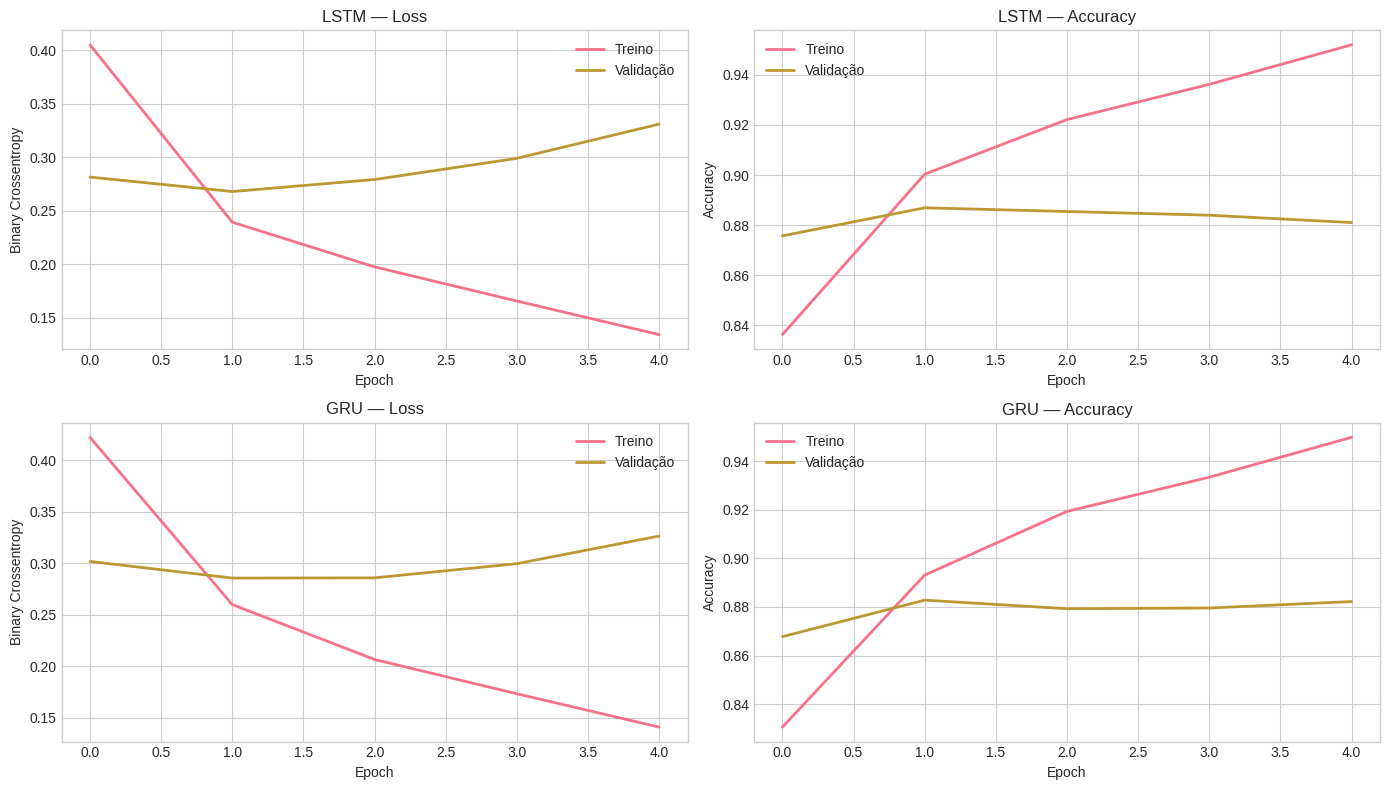

💡 Interpretação:
   - Se val_loss sobe enquanto train_loss desce → OVERFITTING
   - Se ambas descem juntas → bom ajuste
   - O EarlyStopping parou quando val_loss parou de melhorar


In [19]:
# ============================================================
# 7.1 — CURVAS DE TREINAMENTO LSTM vs GRU
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# --- LSTM Loss ---
axes[0, 0].plot(history_lstm.history["loss"], label="Treino", linewidth=2)
axes[0, 0].plot(history_lstm.history["val_loss"], label="Validação", linewidth=2)
axes[0, 0].set_title("LSTM — Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Binary Crossentropy")
axes[0, 0].legend()

# --- LSTM Accuracy ---
axes[0, 1].plot(history_lstm.history["accuracy"], label="Treino", linewidth=2)
axes[0, 1].plot(history_lstm.history["val_accuracy"], label="Validação", linewidth=2)
axes[0, 1].set_title("LSTM — Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend()

# --- GRU Loss ---
axes[1, 0].plot(history_gru.history["loss"], label="Treino", linewidth=2)
axes[1, 0].plot(history_gru.history["val_loss"], label="Validação", linewidth=2)
axes[1, 0].set_title("GRU — Loss")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Binary Crossentropy")
axes[1, 0].legend()

# --- GRU Accuracy ---
axes[1, 1].plot(history_gru.history["accuracy"], label="Treino", linewidth=2)
axes[1, 1].plot(history_gru.history["val_accuracy"], label="Validação", linewidth=2)
axes[1, 1].set_title("GRU — Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("💡 Interpretação:")
print("   - Se val_loss sobe enquanto train_loss desce → OVERFITTING")
print("   - Se ambas descem juntas → bom ajuste")
print("   - O EarlyStopping parou quando val_loss parou de melhorar")

## 8️⃣ Comparação Consolidada: ML Clássico vs Redes Neurais

Agora vamos colocar **todos os modelos lado a lado** e analisar:
- Qual tem melhor performance?
- A rede neural sempre vence o TF-IDF?
- Qual o trade-off entre complexidade e resultado?

In [20]:
# ============================================================
# 8.1 — TABELA COMPARATIVA
# ============================================================

resultados = pd.DataFrame([
    {"Modelo": "Logistic Regression + TF-IDF", "Tipo": "ML Clássico",
     "Accuracy": acc_lr, "F1": f1_lr, "Precision": prec_lr,
     "Recall": rec_lr, "ROC-AUC": auc_lr},
    {"Modelo": "Naive Bayes + TF-IDF", "Tipo": "ML Clássico",
     "Accuracy": acc_nb, "F1": f1_nb, "Precision": prec_nb,
     "Recall": rec_nb, "ROC-AUC": auc_nb},
    {"Modelo": "LSTM (Embedding)", "Tipo": "Rede Neural",
     "Accuracy": acc_lstm, "F1": f1_lstm, "Precision": prec_lstm,
     "Recall": rec_lstm, "ROC-AUC": auc_lstm},
    {"Modelo": "GRU (Embedding)", "Tipo": "Rede Neural",
     "Accuracy": acc_gru, "F1": f1_gru, "Precision": prec_gru,
     "Recall": rec_gru, "ROC-AUC": auc_gru},
]).sort_values("F1", ascending=False).reset_index(drop=True)

print("🏆 RANKING DE MODELOS — Análise de Sentimento (Reviews de Roupas)")
print("=" * 80)
print(resultados.to_string(index=False, float_format="{:.4f}".format))
print("=" * 80)

# Melhor modelo
melhor = resultados.iloc[0]
print(f"\n🥇 Melhor modelo: {melhor['Modelo']} (F1={melhor['F1']:.4f})")

🏆 RANKING DE MODELOS — Análise de Sentimento (Reviews de Roupas)
                      Modelo        Tipo  Accuracy     F1  Precision  Recall  ROC-AUC
Logistic Regression + TF-IDF ML Clássico    0.8808 0.9303     0.8921  0.9720   0.9255
            LSTM (Embedding) Rede Neural    0.8831 0.9297     0.9165  0.9432   0.9179
             GRU (Embedding) Rede Neural    0.8775 0.9265     0.9113  0.9421   0.9091
        Naive Bayes + TF-IDF ML Clássico    0.8552 0.9181     0.8549  0.9914   0.9206

🥇 Melhor modelo: Logistic Regression + TF-IDF (F1=0.9303)


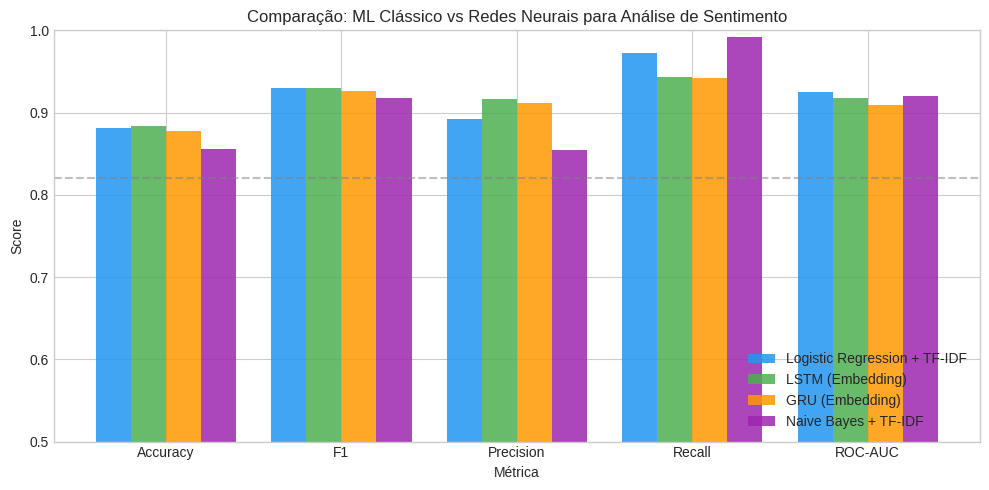

In [21]:
# ============================================================
# 8.2 — GRÁFICO COMPARATIVO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

metricas_plot = ["Accuracy", "F1", "Precision", "Recall", "ROC-AUC"]
x = np.arange(len(metricas_plot))
width = 0.2

cores = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

for i, (_, row) in enumerate(resultados.iterrows()):
    valores = [row[m] for m in metricas_plot]
    ax.bar(x + i * width, valores, width, label=row["Modelo"], color=cores[i], alpha=0.85)

ax.set_xlabel("Métrica")
ax.set_ylabel("Score")
ax.set_title("Comparação: ML Clássico vs Redes Neurais para Análise de Sentimento")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metricas_plot)
ax.legend(loc="lower right")
ax.set_ylim(0.5, 1.0)
ax.axhline(y=0.82, color="gray", linestyle="--", alpha=0.5, label="Baseline 82%")

plt.tight_layout()
plt.show()

## 9️⃣ Avaliação Detalhada: Confusion Matrix e Análise de Erros

Vamos analisar **onde** o melhor modelo erra mais — isso ajuda a entender limitações e possíveis vieses.

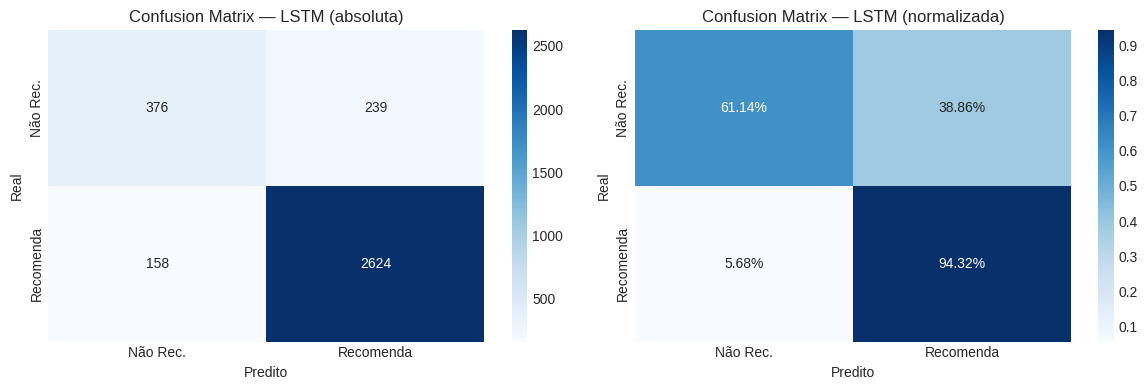


📊 Classification Report — LSTM:
               precision    recall  f1-score   support

Não Recomenda       0.70      0.61      0.65       615
    Recomenda       0.92      0.94      0.93      2782

     accuracy                           0.88      3397
    macro avg       0.81      0.78      0.79      3397
 weighted avg       0.88      0.88      0.88      3397



In [22]:
# ============================================================
# 9.1 — CONFUSION MATRIX DO MELHOR MODELO
# ============================================================
# Usamos o melhor modelo neural (LSTM) para análise detalhada.

# Identificar qual modelo neural foi melhor
if f1_lstm >= f1_gru:
    melhor_pred = y_pred_lstm
    melhor_proba = y_proba_lstm
    melhor_nome = "LSTM"
    melhor_modelo_keras = modelo_lstm
    melhor_history = history_lstm
else:
    melhor_pred = y_pred_gru
    melhor_proba = y_proba_gru
    melhor_nome = "GRU"
    melhor_modelo_keras = modelo_gru
    melhor_history = history_gru

# Confusion Matrix
cm = confusion_matrix(y_test, melhor_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz absoluta
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Não Rec.", "Recomenda"],
            yticklabels=["Não Rec.", "Recomenda"])
axes[0].set_title(f"Confusion Matrix — {melhor_nome} (absoluta)")
axes[0].set_xlabel("Predito")
axes[0].set_ylabel("Real")

# Matriz normalizada
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=axes[1],
            xticklabels=["Não Rec.", "Recomenda"],
            yticklabels=["Não Rec.", "Recomenda"])
axes[1].set_title(f"Confusion Matrix — {melhor_nome} (normalizada)")
axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

# Classification Report completo
print(f"\n📊 Classification Report — {melhor_nome}:")
print(classification_report(y_test, melhor_pred,
                            target_names=["Não Recomenda", "Recomenda"]))

In [23]:
# ============================================================
# 9.2 — ANÁLISE DE ERROS POR CATEGORIA DE PRODUTO
# ============================================================
# Será que o modelo erra mais em certas categorias?
# Isso pode indicar viés nos dados ou variância no estilo de escrita.

# Criar DataFrame com predições para análise
# Precisamos dos índices originais do teste
df_test = df.iloc[-len(y_test):].copy().reset_index(drop=True)

# Se o DataFrame não tiver exatamente o mesmo tamanho, recriamos
# a partir dos índices corretos
df_analise = pd.DataFrame({
    "texto": X_test,
    "real": y_test,
    "predito": melhor_pred,
    "probabilidade": melhor_proba,
    "acertou": (y_test == melhor_pred),
})

# Adicionar departamento se disponível
if "Department Name" in df.columns:
    # Usar os últimos registros que correspondem ao teste
    # (mesma seed = mesma ordem)
    _, temp_idx = train_test_split(
        np.arange(len(df)), test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )
    _, test_idx = train_test_split(
        temp_idx, test_size=0.50, random_state=RANDOM_STATE, stratify=y[temp_idx]
    )
    df_analise["departamento"] = df["Department Name"].iloc[test_idx].values

    # Accuracy por departamento
    print("🏪 Accuracy por Departamento:")
    print("=" * 50)
    acc_por_dept = df_analise.groupby("departamento")["acertou"].agg(["mean", "count"])
    acc_por_dept.columns = ["Accuracy", "Nº Reviews"]
    acc_por_dept = acc_por_dept.sort_values("Accuracy")
    print(acc_por_dept.to_string(float_format="{:.4f}".format))

# Análise de erros: reviews com maior "surpresa" (erros com alta confiança)
erros = df_analise[~df_analise["acertou"]].copy()
erros["confianca"] = np.abs(erros["probabilidade"] - 0.5)
erros_confusos = erros.nlargest(5, "confianca")

print(f"\n\n⚠️ Top 5 erros mais 'confiantes' (modelo errou COM certeza):")
print("=" * 70)
for _, row in erros_confusos.iterrows():
    real_label = "Recomenda" if row["real"] == 1 else "Não Rec."
    pred_label = "Recomenda" if row["predito"] == 1 else "Não Rec."
    print(f"  Real: {real_label} | Predito: {pred_label} | Prob: {row['probabilidade']:.3f}")
    print(f"  Texto: '{row['texto'][:120]}...'")
    print()

🏪 Accuracy por Departamento:
              Accuracy  Nº Reviews
departamento                      
Trend           0.8182          11
Jackets         0.8528         163
Dresses         0.8742         906
Bottoms         0.8855         585
Tops            0.8874        1474
Intimate        0.9062         256


⚠️ Top 5 erros mais 'confiantes' (modelo errou COM certeza):
  Real: Não Rec. | Predito: Recomenda | Prob: 1.000
  Texto: 'didnt realize much would love wore work day got compliment long time outfit comfortable easy flattering bought totally w...'

  Real: Não Rec. | Predito: Recomenda | Prob: 1.000
  Texto: 'bought jacket regular returned store petite lovely live perfect evening remember buy warmth light cover make outfit anyt...'

  Real: Não Rec. | Predito: Recomenda | Prob: 0.997
  Texto: 'found dress run large like reviewer mentioned quality really nice sweater fabric nice touch hit right knee purplish pink...'

  Real: Não Rec. | Predito: Recomenda | Prob: 0.996
  Texto: 'th

## 🟢 1️⃣0️⃣ Discussão Ética: Viés em Reviews e Impacto de Decisões Automatizadas

### ⚠️ Pontos críticos para refletir:

**1. Viés nos dados de treino:**
- O dataset tem reviews majoritariamente de **mulheres de classe média/alta** comprando online
- Faixas etárias, estilos de escrita e expectativas variam por demografia
- Um modelo treinado nesses dados pode não generalizar para outros públicos

**2. Desbalanceamento de classes:**
- ~82% das reviews são positivas (recomenda) — o modelo já "nasce" enviesado para prever positivo
- Reviews negativas são mais informativas para melhoria de produto, mas são minoria

**3. Impacto em decisões de negócio:**
- Se o modelo classifica erroneamente reviews negativas como positivas, **problemas de qualidade passam despercebidos**
- Fornecedores podem ser injustamente penalizados ou beneficiados
- Decisões de estoque baseadas em sentimento enviesado podem gerar prejuízo

**4. Limitações do modelo:**
- Sarcásmo e ironia são difíceis de captar (`"Great, another dress that doesn't fit"` → negativo!)
- Reviews muito curtas têm pouco sinal para o modelo
- O modelo não entende **contexto visual** ("the color is nothing like the photo")

### 💡 Boas práticas:
- Sempre reportar performance **por subgrupo** (departamento, faixa etária)
- Manter humanos no loop para decisões críticas
- Monitorar **drift** do modelo em produção (distribuição de sentimento muda com o tempo)

## 1️⃣1️⃣ Persistência: Salvar Modelos, Tokenizer e Resultados

Salvamos o melhor modelo neural (`.keras`), o Tokenizer (para processar novos textos) e o vetorizador TF-IDF (para o baseline). Na **Aula 9** (Deploy com FastAPI), vamos carregar esses artefatos para servir predições via API.

In [24]:
# ============================================================
# 11.1 — SALVAR MODELOS E ARTEFATOS
# ============================================================

VERSION_SUFFIX = "sentimento_reviews_v1"

# --- Melhor modelo neural (LSTM ou GRU) ---
modelo_keras_path = os.path.join(MODELOS_DIR, f"{melhor_nome.lower()}_{VERSION_SUFFIX}.keras")
melhor_modelo_keras.save(modelo_keras_path)

# --- Tokenizer do Keras (para processar novos textos) ---
tokenizer_path = os.path.join(MODELOS_DIR, f"tokenizer_{VERSION_SUFFIX}.joblib")
joblib.dump(tokenizer, tokenizer_path)

# --- Vetorizador TF-IDF (para baseline) ---
tfidf_path = os.path.join(MODELOS_DIR, f"tfidf_{VERSION_SUFFIX}.joblib")
joblib.dump(tfidf, tfidf_path)

# --- Modelo Logistic Regression (melhor baseline) ---
lr_path = os.path.join(MODELOS_DIR, f"lr_{VERSION_SUFFIX}.joblib")
joblib.dump(lr, lr_path)

# --- CSV consolidado de resultados ---
resultados_csv = "resultados_aula06.csv"
resultados.to_csv(resultados_csv, index=False)

print("✅ Artefatos finais salvos:")
for caminho in [modelo_keras_path, tokenizer_path, tfidf_path, lr_path]:
    kb = os.path.getsize(caminho) / 1024
    print(f"   💾 {caminho}  ({kb:.1f} KB)")
print(f"   📋 {resultados_csv}")

print(f"\n📁 Conteúdo de {MODELOS_DIR}:")
for f in sorted(os.listdir(MODELOS_DIR)):
    tamanho_kb = os.path.getsize(os.path.join(MODELOS_DIR, f)) / 1024
    print(f"   • {f}  ({tamanho_kb:.1f} KB)")

✅ Artefatos finais salvos:
   💾 ../modelos/aula06/lstm_sentimento_reviews_v1.keras  (11695.9 KB)
   💾 ../modelos/aula06/tokenizer_sentimento_reviews_v1.joblib  (545.1 KB)
   💾 ../modelos/aula06/tfidf_sentimento_reviews_v1.joblib  (390.7 KB)
   💾 ../modelos/aula06/lr_sentimento_reviews_v1.joblib  (79.0 KB)
   📋 resultados_aula06.csv

📁 Conteúdo de ../modelos/aula06:
   • lr_sentimento_reviews_v1.joblib  (79.0 KB)
   • lstm_sentimento_reviews_v1.keras  (11695.9 KB)
   • tfidf_sentimento_reviews_v1.joblib  (390.7 KB)
   • tokenizer_sentimento_reviews_v1.joblib  (545.1 KB)


In [25]:
# ============================================================
# 11.2 — SMOKE TEST: RECARREGAR E PREDIZER
# ============================================================
# Verificar que tudo funciona ao recarregar do disco.

# Recarregar modelo neural
modelo_recarregado = keras.models.load_model(modelo_keras_path)
tokenizer_recarregado = joblib.load(tokenizer_path)

# Recarregar baseline
lr_recarregado = joblib.load(lr_path)
tfidf_recarregado = joblib.load(tfidf_path)

# Testar com uma review nova (simulação)
review_teste = "This dress is absolutely beautiful! The fabric quality is amazing and it fits perfectly."

# Pipeline neural
texto_limpo = preprocessar_texto(review_teste)
seq = tokenizer_recarregado.texts_to_sequences([texto_limpo])
pad = pad_sequences(seq, maxlen=MAX_LENGTH, padding="pre", truncating="pre")
prob_neural = modelo_recarregado.predict(pad, verbose=0)[0][0]

# Pipeline baseline
tfidf_vec = tfidf_recarregado.transform([texto_limpo])
prob_lr = lr_recarregado.predict_proba(tfidf_vec)[0][1]

print("🔁 Smoke Test — Modelos recarregados do disco:")
print(f"\n   Review: '{review_teste}'")
print(f"\n   🧠 {melhor_nome}: prob(recomenda) = {prob_neural:.4f} → {'Recomenda' if prob_neural >= 0.5 else 'Não Recomenda'}")
print(f"   📊 LR+TF-IDF: prob(recomenda) = {prob_lr:.4f} → {'Recomenda' if prob_lr >= 0.5 else 'Não Recomenda'}")

# Teste com review negativa
review_neg = "Terrible quality. The fabric is cheap and it fell apart after one wash. Do not buy."
texto_limpo_neg = preprocessar_texto(review_neg)
seq_neg = tokenizer_recarregado.texts_to_sequences([texto_limpo_neg])
pad_neg = pad_sequences(seq_neg, maxlen=MAX_LENGTH, padding="pre", truncating="pre")
prob_neural_neg = modelo_recarregado.predict(pad_neg, verbose=0)[0][0]
tfidf_neg = tfidf_recarregado.transform([texto_limpo_neg])
prob_lr_neg = lr_recarregado.predict_proba(tfidf_neg)[0][1]

print(f"\n   Review: '{review_neg}'")
print(f"\n   🧠 {melhor_nome}: prob(recomenda) = {prob_neural_neg:.4f} → {'Recomenda' if prob_neural_neg >= 0.5 else 'Não Recomenda'}")
print(f"   📊 LR+TF-IDF: prob(recomenda) = {prob_lr_neg:.4f} → {'Recomenda' if prob_lr_neg >= 0.5 else 'Não Recomenda'}")

print("\n✅ Todos os modelos foram carregados e predizem corretamente!")

🔁 Smoke Test — Modelos recarregados do disco:

   Review: 'This dress is absolutely beautiful! The fabric quality is amazing and it fits perfectly.'

   🧠 LSTM: prob(recomenda) = 0.9882 → Recomenda
   📊 LR+TF-IDF: prob(recomenda) = 0.9380 → Recomenda

   Review: 'Terrible quality. The fabric is cheap and it fell apart after one wash. Do not buy.'

   🧠 LSTM: prob(recomenda) = 0.1841 → Não Recomenda
   📊 LR+TF-IDF: prob(recomenda) = 0.1224 → Não Recomenda

✅ Todos os modelos foram carregados e predizem corretamente!


---

## 📝 Atividade Complementar (Tempo estimado: 1h)

### Objetivo

Explorar o impacto de um hiperparâmetro simples na performance do modelo neural e analisar as palavras mais influentes no baseline.

### Tarefas

**Tarefa 1 — Aumentar o MAX_LENGTH de 150 para 250**

O `MAX_LENGTH=150` trunca reviews longas. Será que reviews longas contêm informação útil que estamos perdendo?

- Redefina `MAX_LENGTH = 250`
- Refazer o padding com o novo tamanho
- Criar e treinar um novo modelo LSTM (mesma arquitetura)
- Comparar F1 e ROC-AUC com o modelo original (MAX_LENGTH=150)
- **Pergunta:** Aumentar o comprimento melhorou? O que isso indica sobre as reviews deste dataset?

**Tarefa 2 — Analisar as Top 20 palavras mais influentes na Logistic Regression**

A Logistic Regression com TF-IDF permite ver **quais palavras** mais influenciam a decisão:
- Coeficientes **positivos altos** = palavras que indicam "recomenda"
- Coeficientes **negativos baixos** = palavras que indicam "não recomenda"

- Extraia os coeficientes com `lr.coef_[0]`
- Obtenha os nomes das features com `tfidf.get_feature_names_out()`
- Plote um gráfico de barras com as **10 palavras mais positivas** e **10 mais negativas**
- **Pergunta:** As palavras fazem sentido intuitivo? Alguma surpreende?

> 💡 **Dica:** Use as células-esqueleto abaixo como ponto de partida.

In [ ]:
# ============================================================
# TAREFA 1 — LSTM com MAX_LENGTH = 250
# ============================================================

MAX_LENGTH_NOVO = 250  # Aumentamos de 150 para 250


🏋️ Treinando LSTM com MAX_LENGTH=250...
Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 23s 175ms/step - accuracy: 0.8363 - loss: 0.4095 - val_accuracy: 0.8784 - val_loss: 0.2878
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 175ms/step - accuracy: 0.9011 - loss: 0.2398 - val_accuracy: 0.8881 - val_loss: 0.2655
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.9245 - loss: 0.1932 - val_accuracy: 0.8831 - val_loss: 0.2831
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.9376 - loss: 0.1643 - val_accuracy: 0.8831 - val_loss: 0.3085
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 178ms/step - accuracy: 0.9472 - loss: 0.1439 - val_accuracy: 0.8784 - val_loss: 0.3240
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

🏆 Comparação:
   LSTM (MAX_LENGTH=150): F1=0.9329 | AUC=0.9183
   LSTM (MAX_LENGTH=250): F1=0.9277 | AUC=0.9163
   Δ F1: -0.52 pp


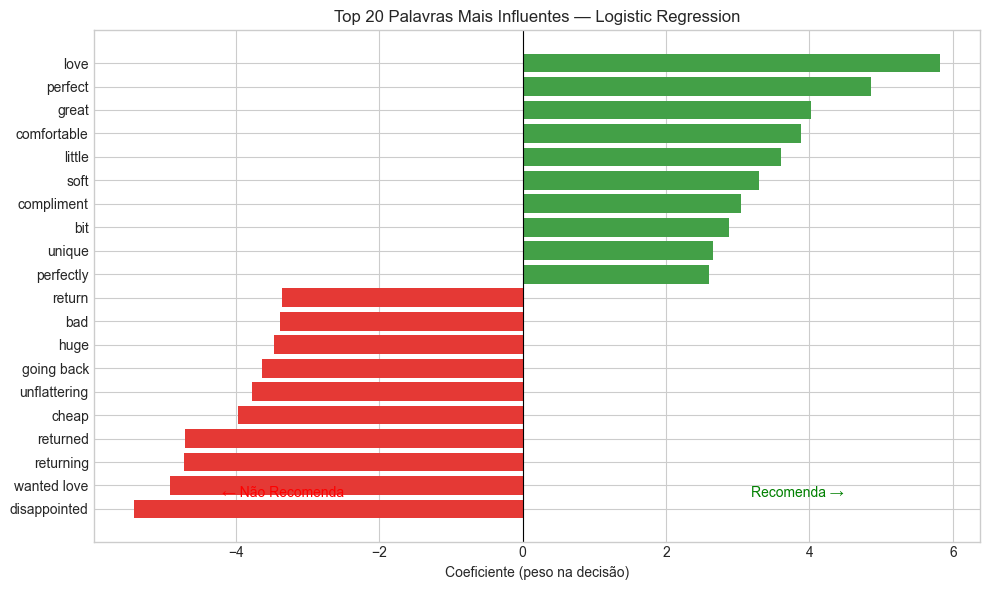


💡 Interpretação:
   Palavras VERDES (coef. positivo) → indicam que o cliente RECOMENDA
   Palavras VERMELHAS (coef. negativo) → indicam que o cliente NÃO recomenda


In [ ]:
# ============================================================
# TAREFA 2 — Palavras mais influentes na Logistic Regression
# ============================================================



Utilize o Stematizador (Stemming)

### ✍️ Reflexão Final

**Responda abaixo (clique duas vezes nesta célula para editar):**

1. **O modelo neural (LSTM/GRU) venceu o baseline (TF-IDF + Logistic Regression)? A diferença justifica a complexidade adicional?**
   - Resposta: *(escreva aqui)*

2. **Olhando a análise de erros por departamento, alguma categoria teve accuracy significativamente menor? O que isso pode indicar?**
   - Resposta: *(escreva aqui)*

3. **Na Tarefa 1, aumentar o MAX_LENGTH de 150 para 250 melhorou o resultado? O que isso diz sobre o tamanho das reviews neste dataset?**
   - Resposta: *(escreva aqui)*

4. **Na Tarefa 2, as palavras mais influentes fazem sentido? Alguma palavra te surpreendeu? Isso ajuda a confiar (ou desconfiar) do modelo?**
   - Resposta: *(escreva aqui)*

5. **Pensando em ética: se esse modelo fosse usado para decidir automaticamente quais fornecedores manter, que riscos você enxerga?**
   - Resposta: *(escreva aqui)*

---

### 🎉 Parabéns!

Você completou a **Aula 6** e agora é capaz de:

- ✅ Pré-processar texto para NLP (tokenização, stopwords, lemmatização)
- ✅ Criar vetores TF-IDF e usar modelos clássicos (LR, Naive Bayes) como baseline
- ✅ Construir redes neurais para texto com **Embedding + LSTM/GRU**
- ✅ Comparar ML clássico vs Redes Neurais objetivamente via MLflow
- ✅ Analisar erros por subgrupo e identificar possíveis vieses
- ✅ Discutir implicações éticas de modelos de sentimento em decisões de negócio
- ✅ Versionar modelos NLP (`.keras` + Tokenizer + TF-IDF em `.joblib`)

**Na próxima aula (Aula 7)**, vamos trabalhar com **LLMs + RAG**: usar modelos de linguagem pré-treinados (GPT) com Retrieval-Augmented Generation para criar um assistente que responde perguntas sobre manuais industriais de teares. 🚀